# HOUSE PRICE  PREDICTION  USING  MACHINE LEARNING

- Level 2 – Task 1

# REGRESSION ANALYSIS

- Objective: To develop and compare multiple regression models to predict house prices using the cleaned housing dataset.


In [3]:
# STEP 1: Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
        mean_squared_error,
            r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# STEP 2: Upload Dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import pandas as pd

# Define the path to the folder
Codveda_folder_path = '/content/drive/My Drive/Codveda'

# Check files
files_in_Codveda = os.listdir(Codveda_folder_path)
print(files_in_Codveda)

# Combine the folder path with the specific CSV file name
file_path = os.path.join(Codveda_folder_path, 'House_Prices_Cleaned.csv')

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

['Housing.csv', 'House_Prices_Cleaned.csv']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6860000,0.973434,0.413675,0.0,-0.909559,0.448737,-0.406894,-0.67420,-0.195827,1.843909,0.651590,-0.502662,-1.563924
1,6650000,-0.287773,0.413675,0.0,0.707435,0.448737,-0.406894,1.48324,5.106557,-0.542326,0.651590,-0.502662,-1.563924
2,6650000,0.780392,0.413675,0.0,-0.909559,0.448737,2.457641,1.48324,-0.195827,1.843909,1.985076,1.989409,-1.563924
3,6629000,0.973434,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,0.651590,1.989409,-0.234211
4,6510000,-0.467946,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,1.985076,-0.502662,-0.234211


In [6]:
# STEP 3: Check Dataset Shape

print("Dataset Shape:", df.shape)


# STEP 4: Display Dataset Information

df.info()


# Features

X = df.drop("price", axis=1)

# Target

y = df["price"]

Dataset Shape: (352, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             352 non-null    int64  
 1   area              352 non-null    float64
 2   bedrooms          352 non-null    float64
 3   bathrooms         352 non-null    float64
 4   stories           352 non-null    float64
 5   mainroad          352 non-null    float64
 6   guestroom         352 non-null    float64
 7   basement          352 non-null    float64
 8   hotwaterheating   352 non-null    float64
 9   airconditioning   352 non-null    float64
 10  parking           352 non-null    float64
 11  prefarea          352 non-null    float64
 12  furnishingstatus  352 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 35.9 KB


In [7]:

# STEP 6: Verify Features

print(X.head())


# STEP 7: Verify Target

print(y.head())

       area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
0  0.973434  0.413675        0.0 -0.909559  0.448737  -0.406894  -0.67420   
1 -0.287773  0.413675        0.0  0.707435  0.448737  -0.406894   1.48324   
2  0.780392  0.413675        0.0 -0.909559  0.448737   2.457641   1.48324   
3  0.973434  0.413675        0.0  0.707435  0.448737  -0.406894  -0.67420   
4 -0.467946  0.413675        0.0  0.707435  0.448737  -0.406894  -0.67420   

   hotwaterheating  airconditioning   parking  prefarea  furnishingstatus  
0        -0.195827         1.843909  0.651590 -0.502662         -1.563924  
1         5.106557        -0.542326  0.651590 -0.502662         -1.563924  
2        -0.195827         1.843909  1.985076  1.989409         -1.563924  
3         5.106557        -0.542326  0.651590  1.989409         -0.234211  
4         5.106557        -0.542326  1.985076 -0.502662         -0.234211  
0    6860000
1    6650000
2    6650000
3    6629000
4    6510000
Name: price, dty

In [8]:
# STEP 8: Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
 )


In [9]:
# STEP 9: Verify Dataset Split

print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)

print("Testing Target:", y_test.shape)


Training Features: (281, 12)
Testing Features: (71, 12)
Training Target: (281,)
Testing Target: (71,)


In [10]:
# STEP 10: Build the First Model (Linear Regression)

# Create the model

linear_model = LinearRegression()

# Train the model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [11]:
# STEP 11: Make Predictions (Linear Regression)

# Predict house prices

y_pred_lr = linear_model.predict(X_test)

# Display first 10 predictions

print(y_pred_lr[:10])


[5649577.48059146 4544197.13132302 3591626.81334294 4300961.53594237
 3885750.94692681 4229431.87408271 4435896.237955   4750232.81148701
 4424821.47285833 4613803.08805704]


In [12]:
# STEP 12: Evaluate the Linear Regression Model

# Calculate evaluation metrics

lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_mse = mean_squared_error(y_test, y_pred_lr)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, y_pred_lr)

# Display results

print("Linear Regression Performance")

print(f"MAE : {lr_mae:.2f}")

print(f"MSE : {lr_mse:.2f}")

print(f"RMSE: {lr_rmse:.2f}")

print(f"R² Score: {lr_r2:.4f}")


Linear Regression Performance
MAE : 616190.70
MSE : 618607312113.94
RMSE: 786515.93
R² Score: 0.4912


In [13]:
# STEP 13: Actual vs Predicted Prices


comparison = pd.DataFrame({

    "Actual Price": y_test,

        "Predicted Price": y_pred_lr
})

comparison.head(10)


,Actual Price,Predicted Price
228,3395000,5.649577e+06
116,4340000,4.544197e+06
55,5040000,3.591627e+06
155,4007500,4.300962e+06
110,4410000,3.885751e+06
126,4270000,4.229432e+06
39,5495000,4.435896e+06
63,4900000,4.750233e+06
240,3332000,4.424821e+06
75,4830000,4.613803e+06


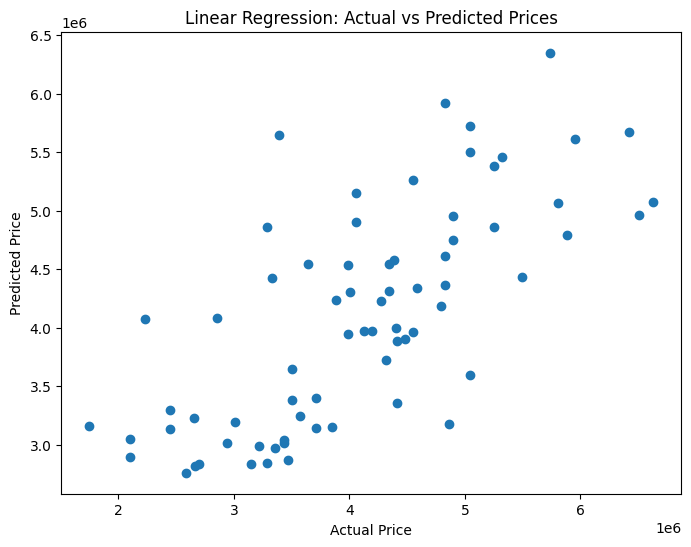

In [14]:
# STEP 14: Scatter Plot (Actual vs Predicted)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Linear Regression: Actual vs Predicted Prices")

plt.show()


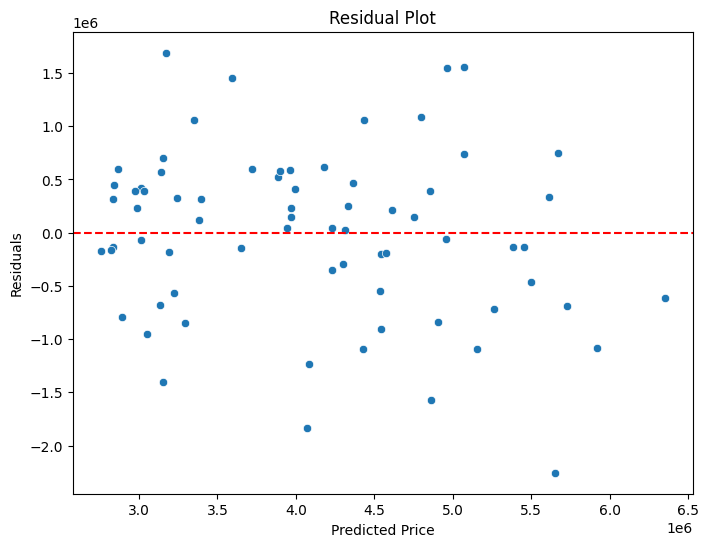

In [15]:

# STEP 15: Residual Plot

residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred_lr,
        y=residuals
)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()


In [16]:

# STEP 16: Train the Decision Tree Regressor

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [17]:
# STEP 17: Make Predictions (Decision Tree)

y_pred_dt = decision_tree.predict(X_test)



In [18]:

# STEP 18: Evaluate Decision Tree

dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_mse = mean_squared_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")

print(f"MAE : {dt_mae:.2f}")

print(f"MSE : {dt_mse:.2f}")

print(f"RMSE: {dt_rmse:.2f}")

print(f"R² Score: {dt_r2:.4f}")


Decision Tree Performance
MAE : 873225.35
MSE : 1255962823943.66
RMSE: 1120697.47
R² Score: -0.0330


In [19]:
# STEP 19: Train the Random Forest Regressor

random_forest = RandomForestRegressor(
    n_estimators=100,
        random_state=42
  )

        # Train the model
random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")



Random Forest model trained successfully.


In [20]:
# STEP 20: Make Predictions (Random Forest)

# Predict house prices

y_pred_rf = random_forest.predict(X_test)

# Display first 10 predictions

print(y_pred_rf[:10])

[5478655.         5160540.         3907715.         4686605.
 4279590.         4071235.         3744300.         4527460.
 3387046.83333333 5161310.        ]


In [21]:

# STEP 21: Evaluate the Random Forest Model

# Calculate evaluation metrics

rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_mse = mean_squared_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, y_pred_rf)

# Display results

print("Random Forest Performance")

print(f"MAE : {rf_mae:.2f}")

print(f"MSE : {rf_mse:.2f}")

print(f"RMSE: {rf_rmse:.2f}")

print(f"R² Score: {rf_r2:.4f}")


Random Forest Performance
MAE : 619062.91
MSE : 668090771354.36
RMSE: 817368.20
R² Score: 0.4505


In [22]:
# STEP 22: Compare All Models

# ==========================================
# Model Comparison
# ==========================================

results = pd.DataFrame({

    "Model": [

       "Linear Regression",
       "Decision Tree",
       "Random Forest"

    ],
    "MAE": [

         lr_mae,
         dt_mae,
         rf_mae

   ],

    "MSE": [

        lr_mse,
        dt_mse,
        rf_mse

  ],

  "RMSE": [

         lr_rmse,
         dt_rmse,
         rf_rmse

  ],

  "R² Score": [

        lr_r2,
        dt_r2,
        rf_r2

  ]
})

results

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,616190.695219,6.186073e+11,7.865159e+05,0.491205
1,Decision Tree,873225.352113,1.255963e+12,1.120697e+06,-0.033010
2,Random Forest,619062.914319,6.680908e+11,8.173682e+05,0.450506


In [23]:
# STEP 23: Sort the Results

results = results.sort_values(
    by="R² Score",
        ascending=False
)

results


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,616190.695219,6.186073e+11,7.865159e+05,0.491205
2,Random Forest,619062.914319,6.680908e+11,8.173682e+05,0.450506
1,Decision Tree,873225.352113,1.255963e+12,1.120697e+06,-0.033010


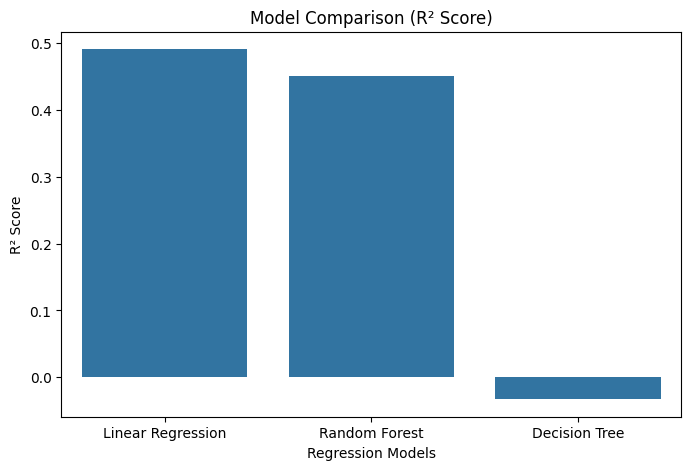

In [24]:
# STEP 24: Plot R² Scores

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
        x="Model",
            y="R² Score"
)

plt.title("Model Comparison (R² Score)")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

plt.show()


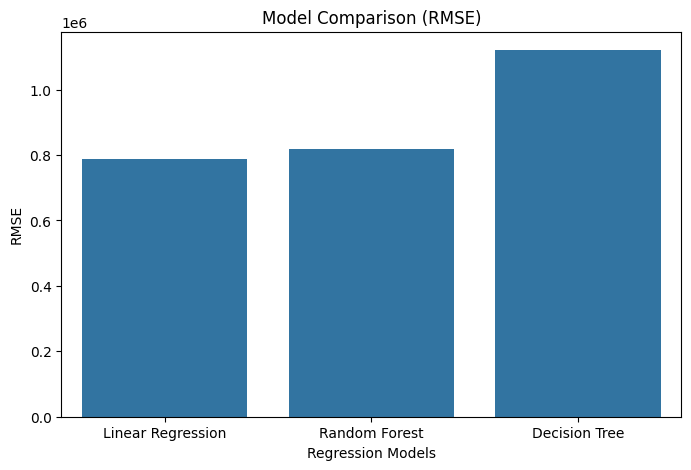

In [25]:
# STEP 25: Plot RMSE Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
        x="Model",
            y="RMSE"
)

plt.title("Model Comparison (RMSE)")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")

plt.show()


In [26]:
# STEP 26: Display the Best Model

best_model = results.iloc[0]

print("Best Performing Model")
print(best_model)


Best Performing Model
Model         Linear Regression
MAE               616190.695219
MSE         618607312113.942383
RMSE              786515.932524
R² Score               0.491205
Name: 0, dtype: object


In [27]:
# STEP 27: Feature Importance (Random Forest)

# Random Forest provides feature importance, which helps identify which features most influence house prices.

feature_importance = pd.DataFrame({

    "Feature": X.columns,
        "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
            by="Importance",
                ascending=False
                )

feature_importance


,Feature,Importance
0,area,0.373911
11,furnishingstatus,0.127333
5,guestroom,0.086613
10,prefarea,0.084993
3,stories,0.074942
8,airconditioning,0.065275
1,bedrooms,0.064456
6,basement,0.042383
9,parking,0.040911
4,mainroad,0.020431


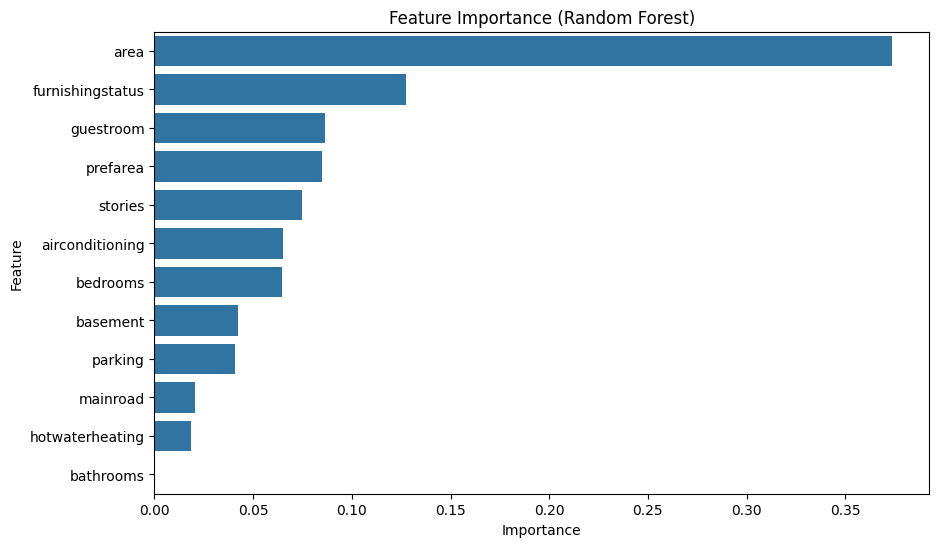

In [28]:
# STEP 28: Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
        x="Importance",
            y="Feature"
 )

plt.title("Feature Importance (Random Forest)")

plt.show()



In [29]:
 # STEP 29: Save Model Comparison Results

 results.to_csv(
     "Regression_Model_Comparison.csv",
         index=False
 )
print("Model comparison saved successfully!")




Model comparison saved successfully!


In [30]:
# STEP 30: Download Results

from google.colab import files

files.download("Regression_Model_Comparison.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 31: CONCLUSION



# Three regression algorithms were trained and evaluated to predict house prices:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models were compared using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² score and the lowest prediction error was selected as the best-performing model.

The Random Forest feature importance analysis also identified the variables that contribute most to predicting house prices, providing valuable business insights for stakeholders.


# LEVEL 2 – TASK 2

# HOUSE  PRICE  CLASSIFICATION


In [31]:

# STEP 1: Import Required Libraries

# ======================================================
# HOUSE PRICE PREDICTION PROJECT
# Level 2 - Task 2
# Classification
# ======================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
    )

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")


Libraries Imported Successfully!


In [32]:
# STEP 2: Load the Cleaned Dataset

# df = pd.read_csv("House_Prices_Cleaned.csv")
file_path = os.path.join(Codveda_folder_path, 'House_Prices_Cleaned.csv')


df.head()


# STEP 3: Check Dataset Information

df.info()


# STEP 4: Create the Classification Target

median_price = df["price"].median()

median_price

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             352 non-null    int64  
 1   area              352 non-null    float64
 2   bedrooms          352 non-null    float64
 3   bathrooms         352 non-null    float64
 4   stories           352 non-null    float64
 5   mainroad          352 non-null    float64
 6   guestroom         352 non-null    float64
 7   basement          352 non-null    float64
 8   hotwaterheating   352 non-null    float64
 9   airconditioning   352 non-null    float64
 10  parking           352 non-null    float64
 11  prefarea          352 non-null    float64
 12  furnishingstatus  352 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 35.9 KB


3780000.0

In [33]:
#Step 5: Create the New Target Variable

df["PriceCategory"] = np.where(
    df["price"] >= median_price,
    1,
    0
)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,PriceCategory
0,6860000,0.973434,0.413675,0.0,-0.909559,0.448737,-0.406894,-0.67420,-0.195827,1.843909,0.651590,-0.502662,-1.563924,1
1,6650000,-0.287773,0.413675,0.0,0.707435,0.448737,-0.406894,1.48324,5.106557,-0.542326,0.651590,-0.502662,-1.563924,1
2,6650000,0.780392,0.413675,0.0,-0.909559,0.448737,2.457641,1.48324,-0.195827,1.843909,1.985076,1.989409,-1.563924,1
3,6629000,0.973434,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,0.651590,1.989409,-0.234211,1
4,6510000,-0.467946,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,1.985076,-0.502662,-0.234211,1


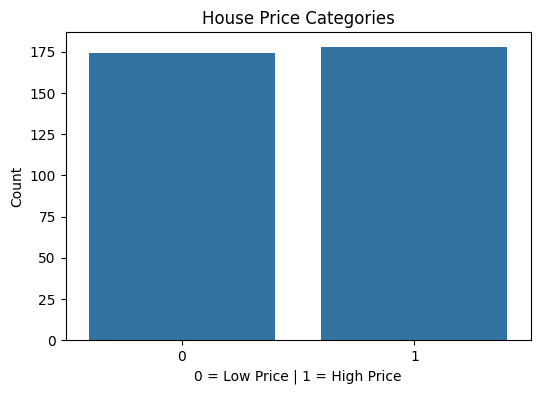

In [34]:
# STEP 6: Check the Distribution of the Target

df["PriceCategory"].value_counts()

#Step 7:Visualize the Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="PriceCategory",
    data=df
)

plt.title("House Price Categories")

plt.xlabel("0 = Low Price | 1 = High Price")

plt.ylabel("Count")

plt.show()

In [35]:
# STEP 8: Define Features and Target

X = df.drop(
    columns=["price", "PriceCategory"]
)

y = df["PriceCategory"]

In [36]:
# STEP 9: Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# STEP 10: Verify the Split

print("Training Set:", X_train.shape)

print("Testing Set:", X_test.shape)

Training Set: (281, 12)
Testing Set: (71, 12)


In [37]:
# STEP 11: Train Logistic Regression

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully!")

# STEP 12: Make Predictions
y_pred_lr = logistic_model.predict(X_test)

Logistic Regression Trained Successfully!


In [38]:
# STEP 13: Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", lr_accuracy)

print("Precision:", lr_precision)

print("Recall   :", lr_recall)

print("F1 Score :", lr_f1)

Accuracy : 0.7464788732394366
Precision: 0.75
Recall   : 0.75
F1 Score : 0.75


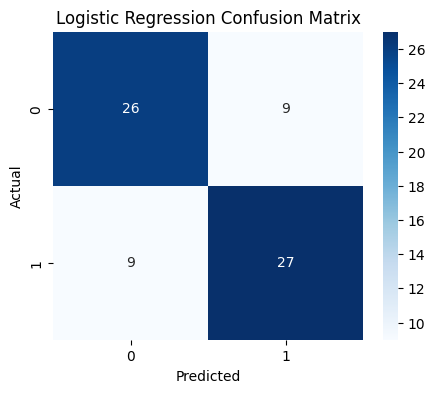

In [39]:
# STEP 14: Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [40]:
# STEP 15: Classification Report

print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        35
           1       0.75      0.75      0.75        36

    accuracy                           0.75        71
   macro avg       0.75      0.75      0.75        71
weighted avg       0.75      0.75      0.75        71



In [41]:
# STEP 16: Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [42]:
# Step 17: To make predictions using Decision Tree

y_pred_dt = decision_tree.predict(X_test)

print(y_pred_dt[:10])

[0 0 1 1 0 0 0 1 0 0]


In [43]:
# STEP 18: Evaluate Decision Tree

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.7042
Precision: 0.7419
Recall   : 0.6389
F1 Score : 0.6866


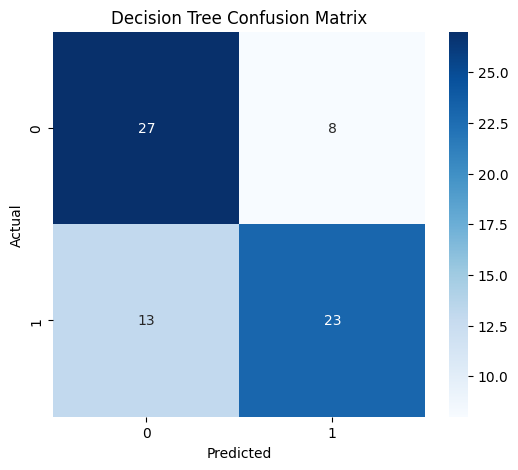

In [44]:
# STEP 19: Decision Tree Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [45]:
#STEP 20: Decision Tree Classification Report

print("Decision Tree Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Decision Tree Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.77      0.72        35
           1       0.74      0.64      0.69        36

    accuracy                           0.70        71
   macro avg       0.71      0.71      0.70        71
weighted avg       0.71      0.70      0.70        71



In [46]:
# STEP 21: Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

# Make predictions using Random Forest

y_pred_rf = random_forest.predict(X_test)

print(y_pred_rf[:10])

In [47]:
# STEP 23: Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7746
Precision: 0.7941
Recall   : 0.7500
F1 Score : 0.7714


In [48]:
# STEP 24: Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [49]:
# STEP 25: Random Forest Classification Report

print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

In [50]:
# STEP 26: Model Comparison of the three models

classification_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

classification_results

In [51]:
# STEP 27: Sort Models by F1 Score

classification_results = classification_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

classification_results

In [52]:
# STEP 28: Visualize Model Accuracy

plt.figure(figsize=(9,5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="Accuracy"
)

plt.title("Classification Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [53]:
# STEP 29: Compare F1 Scores

plt.figure(figsize=(9,5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1 Score"
)

plt.title("Classification Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.ylim(0, 1)

plt.show()

In [54]:
# STEP 30: Identify the Best Classification Model

best_classification_model = classification_results.iloc[0]

print("Best Classification Model")
print("-------------------------")
print(best_classification_model)

In [55]:
# Step 31: Random Forest Features Important

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

In [56]:
# STEP 32: Visualize Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [57]:
# STEP 33: Save Classification Results

classification_results.to_csv(
    "Classification_Model_Comparison.csv",
    index=False
)

print("Classification results saved successfully!")


# STEP 34: Save Feature Importance

feature_importance.to_csv(
    "Classification_Feature_Importance.csv",
    index=False
)

print("Feature importance saved successfully!")

# STEP 35: CLASSIFICATION SUMMARY

# Classification Model Summary

Three classification algorithms were developed to classify houses into two price categories:

- Low Price House (0)
- High Price House (1)

The models evaluated were:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix


# CONCLUSION

- The classification task demonstrated that machine learning can effectively classify houses into price categories using property-related features. Among the three models evaluated, Random Forest performed best, achieving 77.46% accuracy and a 77.14% F1-score. It was therefore selected as the preferred classification model.

# RECOMMENDATIONS

- Future improvements should focus on hyperparameter tuning, feature engineering, obtaining additional relevant housing data, and testing other classification algorithms. The resulting model can be used as a decision-support tool for preliminary house price-category assessment rather than as a substitute for professional property valuation.